# Lab 9 - Cubic Spline Interpolation; Least Squares Approximation

Solutions for tasks 1-4 from `L9_NC.pdf`, implemented in Python.

Formulas follow `NC_lecture7.pdf` (splines intro, Section 2) and `NC_lecture8.pdf` (cubic splines in Section 2.2; least squares in Section 3).

Cubic spline types from the lecture and their `scipy.interpolate` equivalents:

- **Piecewise cubic Hermite** ($m_i = f'(x_i)$ at every node): use `CubicHermiteSpline(x, y, dydx)`. Error $O(|\Delta|^4)$ for $f \in C^4$ (eq. 2.6).
- **Complete (clamped) spline** ($m_1 = f'(a)$, $m_n = f'(b)$, eq. (2.11)): use `CubicSpline(x, y, bc_type=((1, fpa), (1, fpb)))`.
- **Natural cubic spline** ($s''_3(f;a) = s''_3(f;b) = 0$): use `CubicSpline(x, y, bc_type='natural')`.
- **deBoor (not-a-knot) spline** ($p_1 \equiv p_2$, $p_{n-2} \equiv p_{n-1}$, eq. (2.14)): use `CubicSpline(x, y, bc_type='not-a-knot')` (the SciPy default).

For Application 1 we also need:

- **Lagrange polynomial** of degree $n-1$ through $n$ nodes (`scipy.interpolate.lagrange`).
- **Hermite polynomial with double nodes** of degree $2n-1$ matching $(f(x_i), f'(x_i))$ for $i=1,\ldots,n$. With $n$ nodes counted twice this is a single global polynomial; we build it with `scipy.interpolate.KroghInterpolator`, which accepts repeated abscissae and treats consecutive duplicates as derivative data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import (
    CubicSpline,
    CubicHermiteSpline,
    KroghInterpolator,
    lagrange,
)

np.set_printoptions(precision=6, suppress=True)


def hermite_double_nodes(nodes, values, derivatives):
    nodes = np.asarray(nodes, dtype=float)
    values = np.asarray(values, dtype=float)
    derivatives = np.asarray(derivatives, dtype=float)
    xi = np.repeat(nodes, 2)
    yi = np.empty(2 * nodes.size)
    yi[0::2] = values
    yi[1::2] = derivatives
    return KroghInterpolator(xi, yi)


def deboor_spline(x, y):
    return CubicSpline(x, y, bc_type="not-a-knot")


def complete_spline(x, y, fpa, fpb):
    return CubicSpline(x, y, bc_type=((1, fpa), (1, fpb)))


def piecewise_hermite_spline(x, y, dydx):
    return CubicHermiteSpline(x, y, dydx)


## Application 1

$$f(x) = \frac{x+1}{3x^2 + 2x + 1}.$$

By the quotient rule,

$$f'(x) = \frac{(3x^2 + 2x + 1) - (x+1)(6x + 2)}{(3x^2 + 2x + 1)^2} = \frac{-3x^2 - 6x - 1}{(3x^2 + 2x + 1)^2}.$$

We pick 7 equally spaced nodes on $[-2, 4]$ and plot $f$ together with the Lagrange polynomial (degree 6), the global Hermite polynomial with double nodes (degree 13) and the deBoor cubic spline.

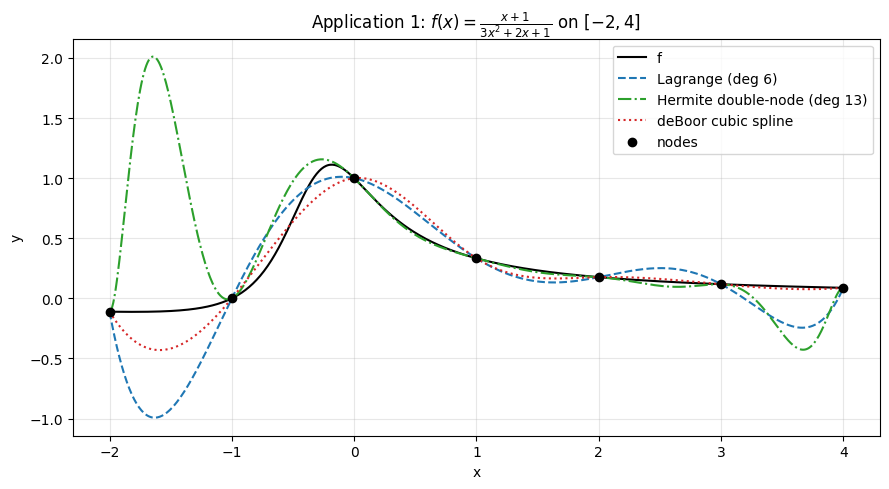

Max absolute error on a dense grid in [-2, 4]:
  Lagrange = 8.8254e-01
  Hermite  = 2.1220e+00
  deBoor   = 3.2137e-01


In [2]:
f1 = lambda x: (x + 1.0) / (3.0 * x**2 + 2.0 * x + 1.0)
f1p = lambda x: (-3.0 * x**2 - 6.0 * x - 1.0) / (3.0 * x**2 + 2.0 * x + 1.0) ** 2

a, b = -2.0, 4.0
nodes1 = np.linspace(a, b, 7)
values1 = f1(nodes1)
derivs1 = f1p(nodes1)

lagrange_poly = lagrange(nodes1, values1)
hermite_poly = hermite_double_nodes(nodes1, values1, derivs1)
deboor1 = deboor_spline(nodes1, values1)

xs = np.linspace(a, b, 600)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, f1(xs), color="black", label="f")
ax.plot(xs, lagrange_poly(xs), color="#1f77b4", linestyle="--", label="Lagrange (deg 6)")
ax.plot(xs, hermite_poly(xs), color="#2ca02c", linestyle="-.", label="Hermite double-node (deg 13)")
ax.plot(xs, deboor1(xs), color="#d62728", linestyle=":", label="deBoor cubic spline")
ax.scatter(nodes1, values1, color="black", zorder=5, label="nodes")
ax.set_title(r"Application 1: $f(x) = \frac{x+1}{3x^2 + 2x + 1}$ on $[-2, 4]$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

errors = {
    "Lagrange": np.max(np.abs(f1(xs) - lagrange_poly(xs))),
    "Hermite": np.max(np.abs(f1(xs) - hermite_poly(xs))),
    "deBoor": np.max(np.abs(f1(xs) - deboor1(xs))),
}
print("Max absolute error on a dense grid in [-2, 4]:")
for name, err in errors.items():
    print(f"  {name:<8} = {err:.4e}")


## Application 2

$f(x) = x \sin(\pi x)$ on the nodes $\{-1, -\tfrac{1}{2}, 0, \tfrac{1}{2}, 1, \tfrac{3}{2}\}$.

$f'(x) = \sin(\pi x) + \pi x \cos(\pi x)$.

We build the deBoor (not-a-knot), complete (with $m_1 = f'(-1)$, $m_n = f'(3/2)$) and piecewise Hermite ($m_i = f'(x_i)$) cubic splines, then plot them with $f$ over $[-1, 3/2]$.

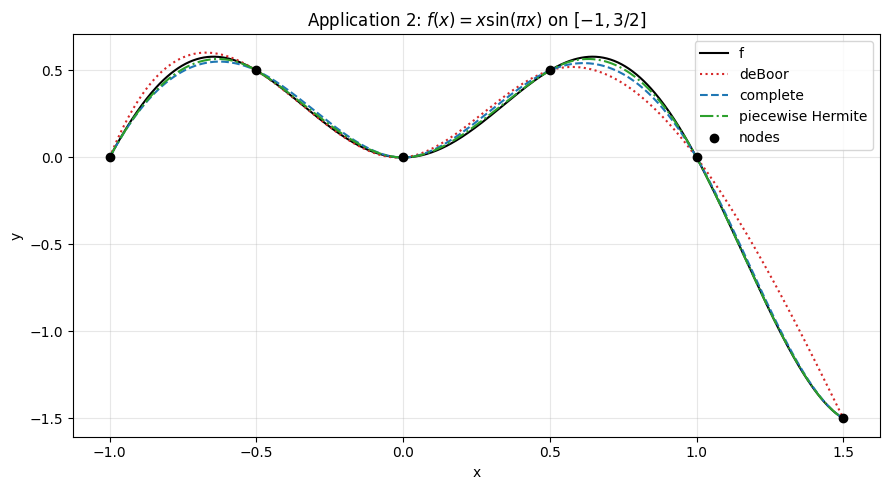

max |f - deBoor            | on dense grid = 2.2058e-01
max |f - complete          | on dense grid = 5.1493e-02
max |f - piecewise Hermite | on dense grid = 2.1492e-02


In [3]:
f2 = lambda x: x * np.sin(np.pi * x)
f2p = lambda x: np.sin(np.pi * x) + np.pi * x * np.cos(np.pi * x)

nodes2 = np.array([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
values2 = f2(nodes2)
derivs2 = f2p(nodes2)

deboor2 = deboor_spline(nodes2, values2)
complete2 = complete_spline(nodes2, values2, f2p(nodes2[0]), f2p(nodes2[-1]))
phermite2 = piecewise_hermite_spline(nodes2, values2, derivs2)

xs = np.linspace(nodes2[0], nodes2[-1], 600)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, f2(xs), color="black", label="f")
ax.plot(xs, deboor2(xs), color="#d62728", linestyle=":", label="deBoor")
ax.plot(xs, complete2(xs), color="#1f77b4", linestyle="--", label="complete")
ax.plot(xs, phermite2(xs), color="#2ca02c", linestyle="-.", label="piecewise Hermite")
ax.scatter(nodes2, values2, color="black", zorder=5, label="nodes")
ax.set_title(r"Application 2: $f(x) = x\sin(\pi x)$ on $[-1, 3/2]$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

for name, spline in [("deBoor", deboor2), ("complete", complete2), ("piecewise Hermite", phermite2)]:
    err = np.max(np.abs(f2(xs) - spline(xs)))
    print(f"max |f - {name:<18}| on dense grid = {err:.4e}")


## Application 3

Discrete least squares (data fitting) for the table

$$
\begin{array}{c|cccccccccc}
x & 0.5 & 1.5 & 2 & 3 & 3.5 & 4.5 & 5 & 6 & 7 & 8 \\
\hline
f & 5 & 5.8 & 5.8 & 6.8 & 6.9 & 7.6 & 7.8 & 8.2 & 9.2 & 9.9
\end{array}
$$

We follow Section 3.3 of `NC_lecture8.pdf`: take the canonical basis $\pi_j(x) = x^{j-1}$ and look for $\varphi^*(x) = \sum c_j \pi_j(x)$ minimising $E^2(\varphi) = \sum_k (\varphi(x_k) - f_k)^2$. The coefficients solve the normal equations $A c = b$ with $a_{ij} = \langle \pi_i, \pi_j \rangle$, $b_i = \langle \pi_i, f \rangle$. `np.polyfit` does exactly this least-squares fit; we report the squared error $E^2$ and the root-mean-square error for several degrees, pick the best fit, then estimate $\varphi^*(4)$ and plot.

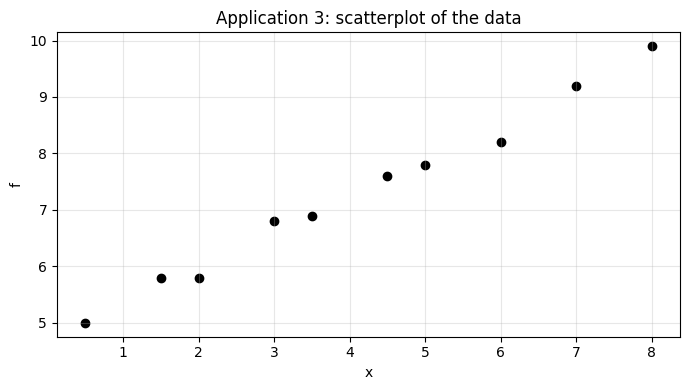

degree      E^2 (SSE)         RMSE   max |residual|
     1       0.209750     0.144827         0.300278
     2       0.199645     0.141296         0.285453
     3       0.152642     0.123548         0.243309
     4       0.145477     0.120614         0.214750


In [4]:
x3 = np.array([0.5, 1.5, 2.0, 3.0, 3.5, 4.5, 5.0, 6.0, 7.0, 8.0])
y3 = np.array([5.0, 5.8, 5.8, 6.8, 6.9, 7.6, 7.8, 8.2, 9.2, 9.9])

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x3, y3, color="black")
ax.set_title("Application 3: scatterplot of the data")
ax.set_xlabel("x")
ax.set_ylabel("f")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'degree':>6} {'E^2 (SSE)':>14} {'RMSE':>12} {'max |residual|':>16}")
for degree in range(1, 5):
    coeffs = np.polyfit(x3, y3, degree)
    fit = np.polyval(coeffs, x3)
    residual = y3 - fit
    sse = float(np.sum(residual ** 2))
    rmse = float(np.sqrt(sse / x3.size))
    print(f"{degree:>6} {sse:>14.6f} {rmse:>12.6f} {np.max(np.abs(residual)):>16.6f}")


The scatterplot looks essentially linear and the residuals confirm it: degree 1 already gives a small RMSE, while degrees 2-4 only marginally improve $E^2$ and risk over-fitting on 10 noisy points. We keep the linear fit $\varphi^*(x) = c_1 + c_2 x$ as the best-fit polynomial, evaluate it at $x = 4$, and plot it on top of the data.

phi*(x) = 0.631725 * x + 4.709926
E^2 = sum of squared residuals = 0.209750
RMSE                            = 0.144827
max |residual|                  = 0.300278
phi*(4) ~= 7.236827


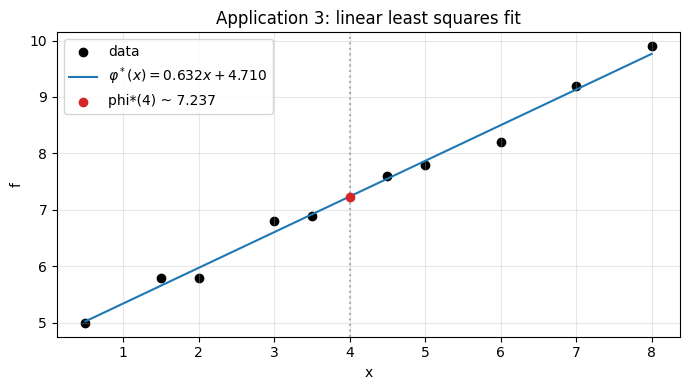

In [5]:
coeffs3 = np.polyfit(x3, y3, 1)
fit3 = lambda x: np.polyval(coeffs3, x)

residual3 = y3 - fit3(x3)
sse3 = float(np.sum(residual3 ** 2))
rmse3 = float(np.sqrt(sse3 / x3.size))

print(f"phi*(x) = {coeffs3[0]:.6f} * x + {coeffs3[1]:.6f}")
print(f"E^2 = sum of squared residuals = {sse3:.6f}")
print(f"RMSE                            = {rmse3:.6f}")
print(f"max |residual|                  = {np.max(np.abs(residual3)):.6f}")
print(f"phi*(4) ~= {fit3(4.0):.6f}")

xs = np.linspace(x3.min(), x3.max(), 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x3, y3, color="black", label="data")
ax.plot(xs, fit3(xs), color="#1f77b4", label=r"$\varphi^*(x) = {:.3f}x + {:.3f}$".format(coeffs3[0], coeffs3[1]))
ax.axvline(4.0, color="gray", linestyle=":", alpha=0.6)
ax.scatter([4.0], [fit3(4.0)], color="#d62728", zorder=5, label=f"phi*(4) ~ {fit3(4.0):.3f}")
ax.set_title("Application 3: linear least squares fit")
ax.set_xlabel("x")
ax.set_ylabel("f")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Application 4

Pressure of water vapours $P$ (bar) as a function of temperature $T$ (°C):

$$
\begin{array}{c|cccccccc}
T & 0 & 10 & 20 & 30 & 40 & 60 & 80 & 100 \\
\hline
P & 0.0061 & 0.0123 & 0.0234 & 0.0424 & 0.0738 & 0.1992 & 0.4736 & 1.0133
\end{array}
$$

We fit a quadratic and a cubic least squares polynomial, compare $E^2$ values, estimate $P(45)$ from each fit, and plot.

quadratic  coeffs (high to low) = [ 0.000152 -0.006081  0.050853]
           E^2 = 1.280531e-02, RMSE = 4.000830e-02, max |res| = 6.603079e-02
cubic      coeffs (high to low) = [ 0.000002 -0.000081  0.002377  0.000842]
           E^2 = 2.474335e-04, RMSE = 5.561401e-03, max |res| = 9.058259e-03

P(45) quadratic fit ~= 0.085779 bar
P(45) cubic fit     ~= 0.088133 bar


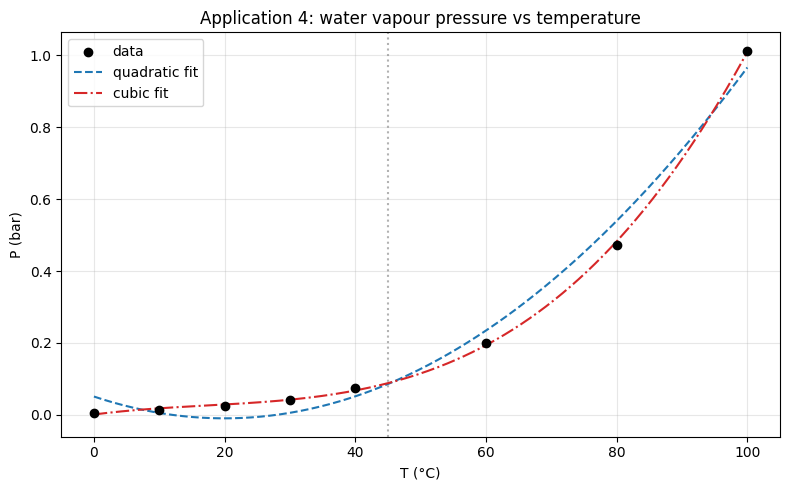

In [6]:
T = np.array([0.0, 10.0, 20.0, 30.0, 40.0, 60.0, 80.0, 100.0])
P = np.array([0.0061, 0.0123, 0.0234, 0.0424, 0.0738, 0.1992, 0.4736, 1.0133])

coeffs_q = np.polyfit(T, P, 2)
coeffs_c = np.polyfit(T, P, 3)

fit_q = lambda x: np.polyval(coeffs_q, x)
fit_c = lambda x: np.polyval(coeffs_c, x)

for name, coeffs, fit in [("quadratic", coeffs_q, fit_q), ("cubic", coeffs_c, fit_c)]:
    residual = P - fit(T)
    sse = float(np.sum(residual ** 2))
    rmse = float(np.sqrt(sse / T.size))
    print(f"{name:<10} coeffs (high to low) = {coeffs}")
    print(f"           E^2 = {sse:.6e}, RMSE = {rmse:.6e}, max |res| = {np.max(np.abs(residual)):.6e}")

print()
print(f"P(45) quadratic fit ~= {fit_q(45.0):.6f} bar")
print(f"P(45) cubic fit     ~= {fit_c(45.0):.6f} bar")

ts = np.linspace(T.min(), T.max(), 400)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(T, P, color="black", zorder=5, label="data")
ax.plot(ts, fit_q(ts), color="#1f77b4", linestyle="--", label="quadratic fit")
ax.plot(ts, fit_c(ts), color="#d62728", linestyle="-.", label="cubic fit")
ax.axvline(45.0, color="gray", linestyle=":", alpha=0.6)
ax.set_title("Application 4: water vapour pressure vs temperature")
ax.set_xlabel("T (°C)")
ax.set_ylabel("P (bar)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


The cubic polynomial gives a substantially smaller $E^2$ than the quadratic, so it is the better fit on this data. Both fits are still imperfect because pressure is exponentially-shaped in temperature: a low-degree polynomial cannot capture both the very small values near $T = 0$ and the rapid growth near $T = 100$. For an extrapolation outside $[0, 100]$ a different model (e.g. fitting $\log P$ versus $T$) would be more appropriate.